In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import DREAMS_utils
import pyEXP
import yaml
import k3d
from gala.units import SimulationUnitSystem
import astropy.units as u
import pynbody


/tmp/ipykernel_1232036/2621941347.py:45: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim([0,10])


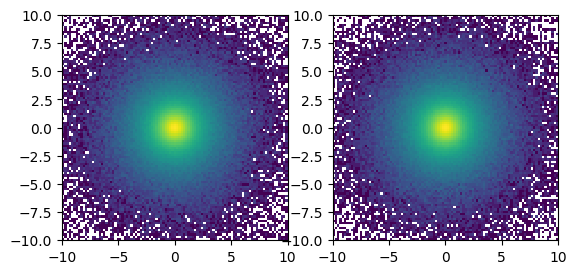

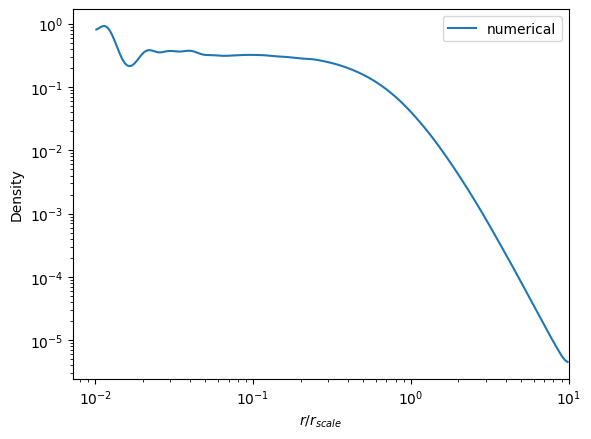

In [2]:
output_dir = "/mnt/home/asante/ceph/PlummerNbody/N6/"

outputs = os.listdir(output_dir)
outputs = [o for o in outputs if ".npz" in o]
# Order files by snapshot
t_outputs = sorted([float(out.replace("Plummer_outs_t","").replace(".npz","")) for out in outputs])
outputs = [f"Plummer_outs_t{int(t):03}.npz" for t in t_outputs]

lims = 10

# Load position, velocity, and masses of particles at last snapshot
data_final = np.load(f"{output_dir}{outputs[-1]}", allow_pickle=True)

# Create pynbody object and center particle distribution
sim = pynbody.new(dark=1000000)
sim["pos"] = data_final["x"]
sim["mass"] = data_final["m"]

pynbody.analysis.center(sim, with_velocity=False)

# Visualize cluster final configuration
fig,ax = plt.subplots(1,2)
_ = ax[0].hist2d(sim["pos"][:,0], sim["pos"][:,1], norm="log", bins=np.linspace(-lims,lims,100))
_ = ax[1].hist2d(sim["pos"][:,0], sim["pos"][:,2], norm="log", bins=np.linspace(-lims,lims,100))
ax[0].set_aspect(1)
ax[1].set_aspect(1)

r = np.sqrt(np.sum(sim["pos"]**2, axis=1))
masses = sim["mass"]

# 1 - Calculate base density
density_params_df = {"bins": 200,
                     "rangevals": [0.01,10]}

rbins, dvals = DREAMS_utils.return_density(r=r, weights=masses, **density_params_df, smooth=True)


# Plot inferred density vs analytical density
fig,ax = plt.subplots()
ax.plot(rbins, dvals, label="numerical")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlabel("$r/r_{scale}$")
ax.set_ylabel("Density")
ax.set_xlim([0,10])
ax.legend()

In [3]:
# 2 - Set up basis
# Create an EXP-compatible spherical basis function table 
model_file = f"{output_dir}basis_empirical_PlummerTest.txt" 
cache_file = model_file.replace(".txt",".cache.run0")

# Check if model or table have already been computed
if os.path.exists(model_file):
    os.remove(model_file)
if os.path.exists(cache_file):
    os.remove(cache_file)

rbins, dvals, mass, potential = DREAMS_utils.makemodel_empirical(rvals=rbins,
                                                                 dvals=dvals,
                                                                 pfile=model_file) 
config = {"id" : "sphereSL",
            "parameters": {"numr": 1000,
                            "rmin": 0.01,
                            "rmax": 10,
                            "Lmax": 6,
                            "nmax": 20,
                            "rmapping": 0.1,
                            "modelname": model_file,
                            "cachename": model_file.replace(".txt",".cache.run0")
                            }
            }


# Save yaml file for constructing gala potential
yaml_file = f"{output_dir}basis_yaml_PlummerTest.yml"

with open(yaml_file, "w") as f:
    yaml.dump(config, f, default_flow_style=False)
    
    
# Construct basis
with open(yaml_file, "r") as f:
    yaml_config = f.read()

# Build the basis
basis = pyEXP.basis.Basis.factory(yaml_config) 


! Scaling:  R= 9.827935816415723   M= 1.0
0.9999999999999999 0.9849335248334261 0.9849335248334261 0.9849335248334261
---- SLGridSph::WriteH5Cache: wrote </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- Spherical::orthoTest: worst=0.010901


---- SLGridSph::ReadH5Cache: error reading </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- SLGridSph::ReadH5Cache: HDF5 error is <Unable to open file /mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0 (File accessibility) Unable to open file>


In [4]:
# 3 - Calculate coefficients
coefs_container = None

for (t, output_file) in zip(t_outputs, outputs):
    
    data_file = np.load(f"{output_dir}{output_file}")
    
    # Center
    sim = pynbody.new(dark=1000000)
    sim["pos"] = data_file["x"]
    sim["mass"] = data_file["m"]

    pynbody.analysis.center(sim, with_velocity=False)

    coefs = basis.createFromArray(sim["mass"],
                                  sim["pos"], 
                                  time=t)
    
    if coefs_container is None:
        coefs_container = pyEXP.coefs.Coefs.makecoefs(coefs)
        coefs_container.add(coefs)
    else:
        coefs_container.add(coefs)
        
# Save the coefficients
coefs_file = f"{output_dir}coefs_PlummerTest.h5"
if os.path.exists(coefs_file):
    os.remove(coefs_file)
    coefs_container.WriteH5Coefs(coefs_file) 
else:
    coefs_container.WriteH5Coefs(coefs_file)
    

(-5.0, 5.0)

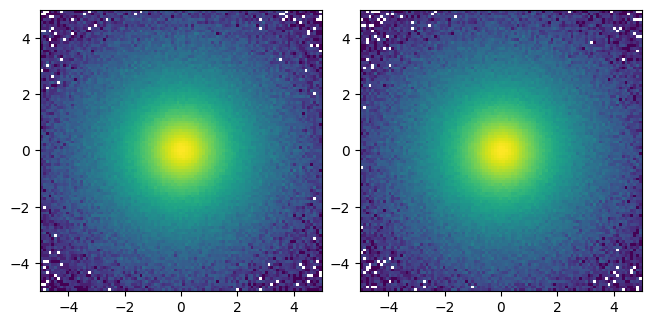

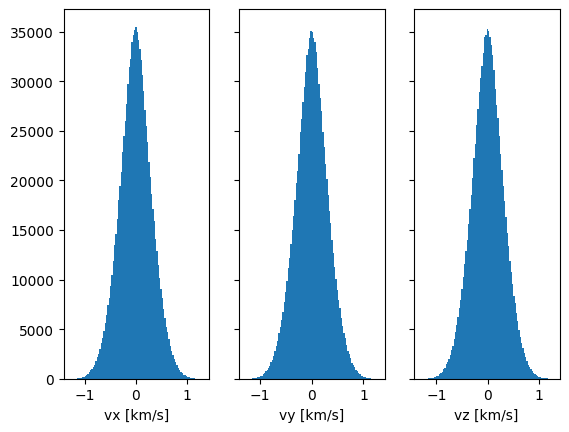

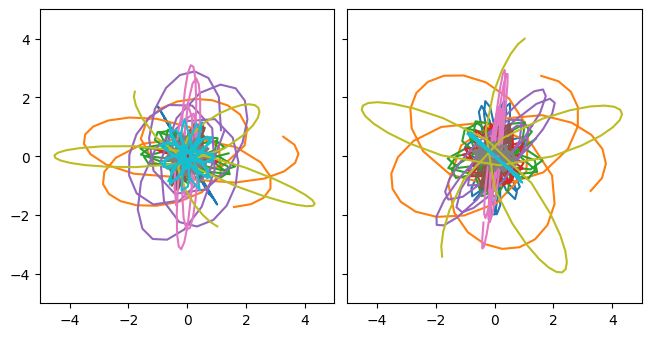

In [5]:
rng = np.random.default_rng(16)

x_lim = 5

xyz = data_file["x"]
fig,ax = plt.subplots(1,2, layout="constrained")
_ = ax[0].hist2d(xyz[:,0], xyz[:,1], norm="log", bins=np.linspace(-x_lim,x_lim,100))
_ = ax[1].hist2d(xyz[:,0], xyz[:,2], norm="log", bins=np.linspace(-x_lim,x_lim,100))
ax[0].set_aspect(1)
ax[1].set_aspect(1)

# Velocity distribution
v_xyz = data_file["v"]
fig1,ax = plt.subplots(1,3, sharey=True)
labels = ["vx [km/s]", "vy [km/s]", "vz [km/s]"]
for i in range(3):
    _ = ax[i].hist(v_xyz[:,i], bins=100)
    ax[i].set_xlabel(labels[i])
    
# Orbits
v_abs = np.sqrt(np.sum(v_xyz**2,axis=1))
idx_list = rng.integers(len(v_xyz), size=10)
fig2,axs = plt.subplots(1,2, layout="constrained", sharex=True, sharey=True)

pos = dict(zip(idx_list, [[] for i in range(len(idx_list))]))
vel = dict(zip(idx_list, [[] for i in range(len(idx_list))]))

for output_file in outputs:
    
    data_file = np.load(f"{output_dir}{output_file}")
    for idx in idx_list:
        x_idx = data_file["x"][idx]
        v_idx = data_file["v"][idx]
        pos[idx].append(x_idx)
        vel[idx].append(v_idx)

for idx in idx_list:
    p_xyz = np.vstack(pos[idx])
    axs[0].plot(p_xyz[:,0],p_xyz[:,1])
    axs[1].plot(p_xyz[:,0],p_xyz[:,2])
    
axs[0].set_aspect(1)
axs[1].set_aspect(1)
axs[0].set_xlim([-x_lim,x_lim])
axs[0].set_ylim([-x_lim,x_lim])

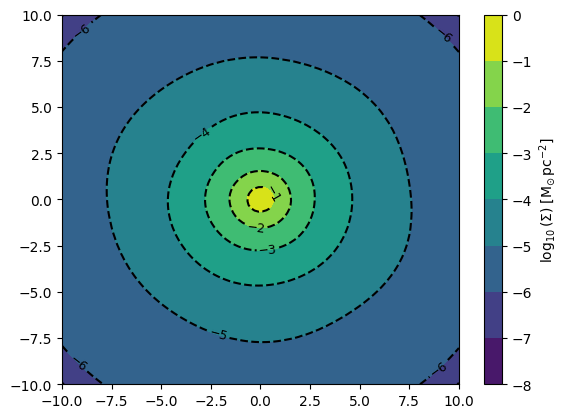

In [6]:
# Initialise surface field generator
times = coefs_container.Times()
field = "dens"
time = times[-1]

lim = 10.
grid = 100

generator = pyEXP.field.FieldGenerator(times, 
                                       [-lim, -lim, 0],
                                       [lim,lim,0],
                                       [grid,grid,0])

surfaces = generator.slices(basis, coefs_container)

surface = surfaces[time][field]

x = np.linspace(-lim,lim,grid)

y = np.linspace(-lim,lim,grid)

xv, yv = np.meshgrid(x, y)

fig, ax = plt.subplots()
cbar_label = field

if field in ["dens", "dens m=0", "dens m>0"]:

    # Convert to M_sun / kpc^2
    surface = np.log10(surface)
        
    cbar_label = "$\\log_{10}(\\Sigma) \\; [\\rm{M}_{\\odot} \\, \\rm{pc}^{-2}]$"

        
if field in ["potl", "potl m=0", "potl m>0"]:
    # Convert to (km/s)^2
    cbar_label = "$\\Phi \\; [\\rm{km}^2 \\, \\rm{s}^{-2}]$"


cont1 = ax.contour(xv, yv, surface, colors='k')
cont1.clabel(fontsize=9, inline=True)
cont2 = ax.contourf(xv, yv, surface)
cbar = fig.colorbar(cont2)
cbar.set_label(cbar_label)


In [7]:
# Visualize basis
field = "dens"
grid_lim = .50
n_points=100
time = coefs_container.Times()[-1]

times = coefs_container.Times()
pmin  = [-grid_lim, -grid_lim, -grid_lim]
pmax  = [grid_lim, grid_lim, grid_lim]
grid  = [n_points, n_points, n_points]

generator = pyEXP.field.FieldGenerator(times, pmin, pmax, grid)
volumes = generator.volumes(basis, coefs_container)

volume = volumes[time][field]

# Initialise plot
plot = k3d.plot()

value_range = [np.percentile(volume, 5), np.percentile(volume, 95)]
size = [-grid_lim, grid_lim, -grid_lim, grid_lim, -grid_lim, grid_lim]

volume = k3d.volume(volume.astype(np.float32), 
                    alpha_coef=250,
                    color_range=value_range,  
                    color_map=(np.array(k3d.colormaps.paraview_color_maps.Blues).reshape(-1,4) 
                    * np.array([1,1.0,1.0,1.0])).astype(np.float32), 
                    compression_level=7)

volume.transform.bounds = [-size[0], size[0], -size[1], size[1], -size[2], size[2]]

plot += volume

plot

Plot(antialias=3, axes=['x', 'y', 'z'], axes_helper=1.0, axes_helper_colors=[16711680, 65280, 255], background…

# Build stream simulation

In [8]:
from gala.units import SimulationUnitSystem, DimensionlessUnitSystem
import gala.potential as gp
import gala.dynamics as gd
import astropy.units as u
from gala.dynamics import mockstream as ms
import gala.integrate as gi
import math 

In [9]:
pot = gp.EXPPotential(units=DimensionlessUnitSystem(),
                      config_file=yaml_file,
                      coef_file=coefs_file)

pot_analytical = gp.PlummerPotential(m=1,
                                     b=1,
                                     units=DimensionlessUnitSystem())

---- SLGridSph::ReadH5Cache: successfully read basis cache </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- Spherical::orthoTest: worst=0.010901


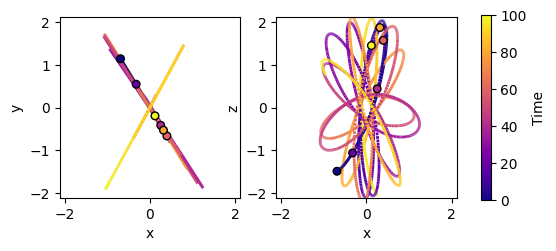

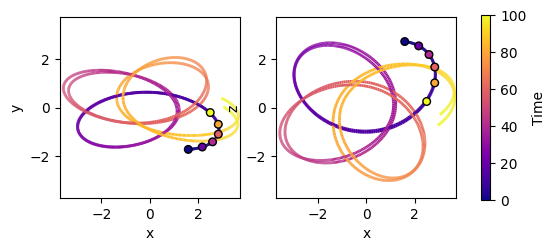

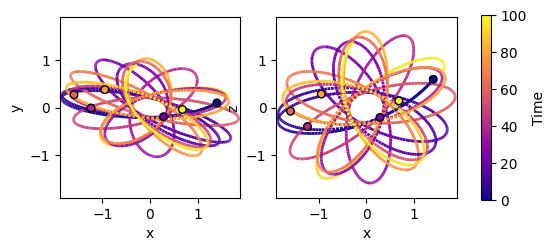

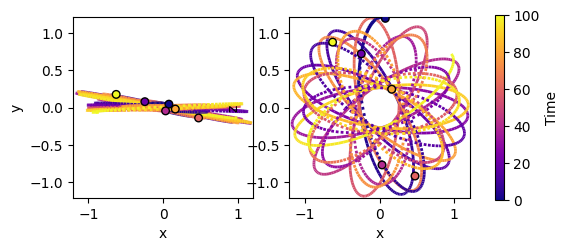

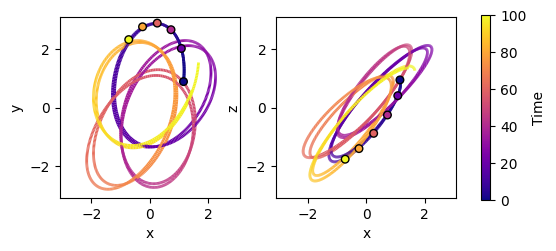

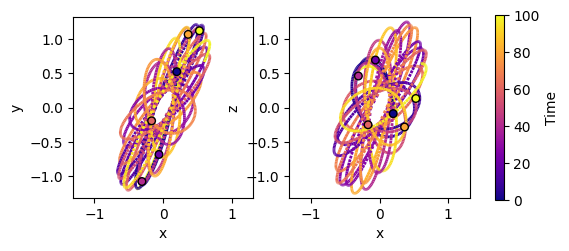

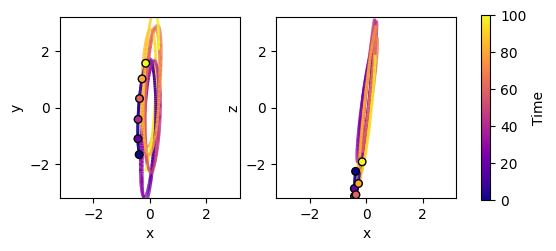

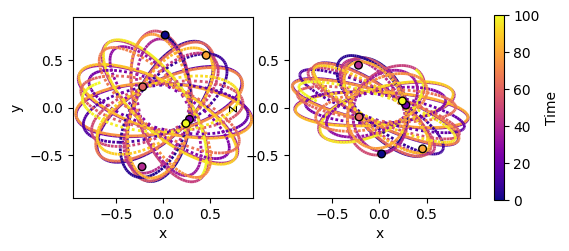

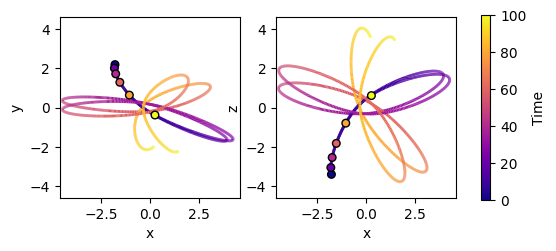

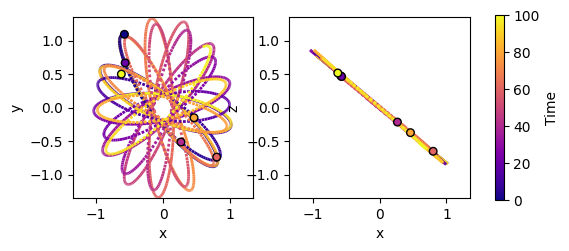

In [10]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

cmap = "plasma"

def plot_colored_line(ax, x, y, c, norm, cmap='viridis', linewidth=2, **kwargs):
    """
    Plots a line with a color gradient based on a third variable 'c'.
    
    Parameters
    ----------
    ax : Matplotlib Axes
        The axes to plot on.
    x, y : array-like
        The x and y coordinates of the data points.
    c : array-like
        The color values (e.g., time) that determine the color of each segment.
    cmap : str, optional
        The colormap to use (default is 'viridis').
    linewidth : int, optional
        The width of the line (default is 2).
    """
    # Create segments by pairing up consecutive points
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # Create a continuous norm to map the 'c' values to colors
    
    # Create the LineCollection
    lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=linewidth, **kwargs)
    
    # Set the color array
    # We use the 'c' values for the first point of each segment
    lc.set_array(c[:-1]) 
    
    # Add the collection to the axes and get the minimum/maximum limits
    ax.add_collection(lc)
    ax.autoscale_view() # Adjust the plot limits to encompass the new line
    
    return lc # Return the LineCollection object to use with a Colorbar


t2=100

for i,k in enumerate(pos.keys()):
    
    color = [rng.uniform(), rng.uniform(), rng.uniform()]
    orbit_xyz = np.vstack(pos[k])
    
    orbit_x0 = pos[k][0]
    orbit_v0 = vel[k][0]
    orbit_w0 = gd.PhaseSpacePosition(pos=orbit_x0,
                                     vel=orbit_v0)

    orbit_r = np.sqrt(np.sum(np.power(orbit_x0,2)))
    
    v_esc = math.sqrt(2*math.pi/orbit_r)

    orbit_period = 5*2*math.pi*orbit_r/v_esc
    
    norm = Normalize(0, t2)
    
    """if orbit_period >= max(t_outputs):
        continue 
    
    elif orbit_period <20:
        continue"""
    

    orbit_analytical = pot_analytical.integrate_orbit(w0=orbit_w0, 
                                                      Integrator=gi.DOPRI853Integrator,
                                                      t1=0, 
                                                      t2=t2, 
                                                      n_steps=1000)

    orbit_EXP = pot.integrate_orbit(w0=orbit_w0, 
                                    Integrator=gi.DOPRI853Integrator, 
                                    t1=0, 
                                    t2=t2, 
                                    n_steps=1000)

    fig,axs = plt.subplots(1,2)
    p = plot_colored_line(axs[0], 
                          x=orbit_analytical.xyz[0], 
                          y=orbit_analytical.xyz[1],
                          c=orbit_analytical.t.value,
                          cmap=cmap,
                          norm=norm,
                          ls="-")
    p = plot_colored_line(axs[0], 
                          x=orbit_EXP.xyz[0], 
                          y=orbit_EXP.xyz[1],
                          c=orbit_EXP.t.value,
                          cmap=cmap,
                          norm=norm,
                          ls=":")
    p = plot_colored_line(axs[1], 
                          x=orbit_analytical.xyz[0], 
                          y=orbit_analytical.xyz[2],
                          c=orbit_analytical.t.value,
                          cmap=cmap,
                          norm=norm,
                          ls="-")
    p = plot_colored_line(axs[1], 
                          x=orbit_EXP.xyz[0], 
                          y=orbit_EXP.xyz[2],
                          c=orbit_EXP.t.value,
                          cmap=cmap,
                          norm=norm,
                          ls=":")
    x = [orbit_xyz[:,0][i] for i in range(len(t_outputs)) if t_outputs[i]<=t2]
    y = [orbit_xyz[:,1][i] for i in range(len(t_outputs)) if t_outputs[i]<=t2]
    z = [orbit_xyz[:,2][i] for i in range(len(t_outputs)) if t_outputs[i]<=t2]
    axs[0].scatter(x, 
               y, 
               c=[t for t in t_outputs if t<=t2], 
               norm=norm,
               edgecolors="k",
               cmap=cmap,
               s=30, label='Simulation', zorder=100)
    
    axs[1].scatter(x, 
               z, 
               c=[t for t in t_outputs if t<=t2], 
               norm=norm,
               edgecolors="k",
               cmap=cmap,
               s=30, label='Simulation', zorder=100)
    
    lims = math.sqrt(max(np.sum(orbit_analytical.xyz.value**2,axis=0)))
    for ax in axs:
        ax.set_xlim([-lims, lims])
        ax.set_ylim([-lims,lims])
        ax.set_aspect(1)
        
    axs[0].set_xlabel("x")
    axs[1].set_xlabel("x")
    axs[0].set_ylabel("y")
    axs[1].set_ylabel("z")
    

    fig.colorbar(p, ax=axs, label='Time', shrink=0.5) 

---- SLGridSph::ReadH5Cache: successfully read basis cache </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- Spherical::orthoTest: worst=0.010901
---- SLGridSph::ReadH5Cache: successfully read basis cache </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- Spherical::orthoTest: worst=0.010901
Simulation done in 11.851819276809692 seconds


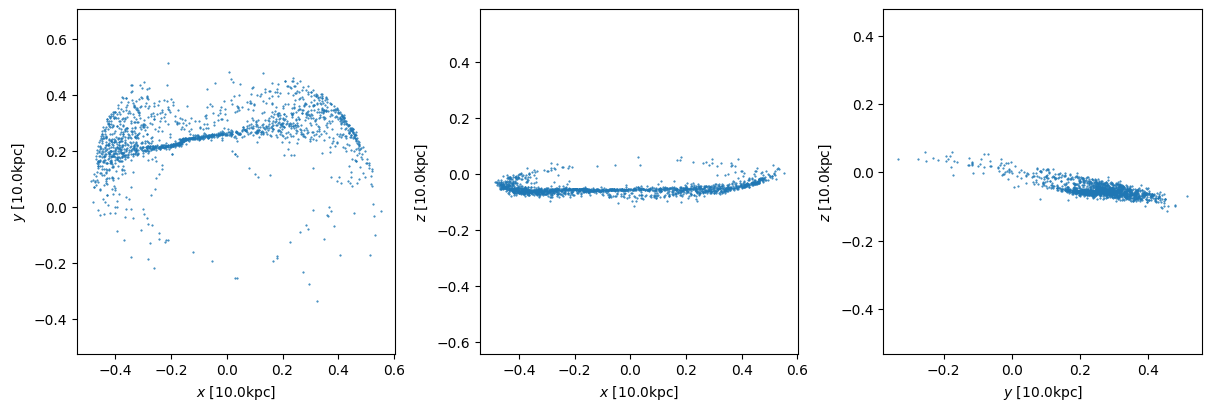

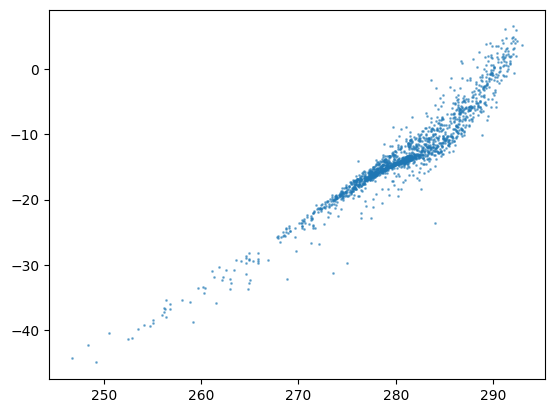

In [18]:
import time
exp_units = SimulationUnitSystem(mass=10**12*u.Msun, # Can decide here how big your system is
                                 length=10*u.kpc, # Specify what's the scale radius
                                 G=1)
pot = gp.EXPPotential(units=exp_units,
                      config_file=yaml_file,
                      coef_file=coefs_file)

# Stream sims parameters
t1 = 0*exp_units["time"]
t2 = 200*exp_units["time"]
n_steps=1000


# Initialise stream ICs
gc_mass = 1e-7*exp_units["mass"]
gc_pot = gp.PlummerPotential(m=gc_mass, 
                             b=4*u.pc, 
                             units=exp_units)

def sample_random_vector():
    v_magnitude = rng.normal(loc=0.0, scale=.3)
    random_components = rng.normal(loc=0.0, scale=1.0, size=3)
    norm = np.linalg.norm(random_components)
    unit_vector = random_components / norm
    return v_magnitude*unit_vector

# x0 = sample_random_vector()
# v0 = sample_random_vector()
x0 = np.array([0.25, 0, 0])
v0 = np.array([0, 0.5, 0])
#print(f"Simulating GC disruption at x0={x0.to(u.kpc)} and v0={v0.to(u.km/u.s)}")
gc_w0 = gd.PhaseSpacePosition(pos=x0,
                              vel=v0)

# Initialise simulation submodels
gen_object = ms.MockStreamGenerator(df=ms.ChenStreamDF(lead=True, trail=True), # stream distribution function 
                                    hamiltonian=pot, # potential within which the stream is disrupted
                                    progenitor_potential=gc_pot 
                                    )
start = time.time()
stream_obj, _ = gen_object.run(prog_w0=gc_w0, # initial (or final) phase-space position of the progenitor system
                               prog_mass=gc_mass, # sets the scale mass of the particle release
                               release_every=1, # how many times particles are released at each time step
                               n_particles=1, # how many particles are released by the trail and the lead of the stream each time. Can be an array with same lenth as the timesteps,
                               t1=t1,
                               t2=t2,
                               n_steps = n_steps,
                               Integrator=gi.LeapfrogIntegrator,
                               )  
print(f"Simulation done in {time.time()-start} seconds")

xyz = stream_obj.xyz.to(u.kpc)

_ = stream_obj.plot(s=1)

import astropy.coordinates as coord

stream_obj_obs = stream_obj.to_coord_frame(coord.ICRS())
fig,ax = plt.subplots()
ax.scatter(stream_obj_obs.ra.value,
           stream_obj_obs.dec.value,
           s=1,
           alpha=0.5)

Simulation done in 0.27817320823669434 seconds


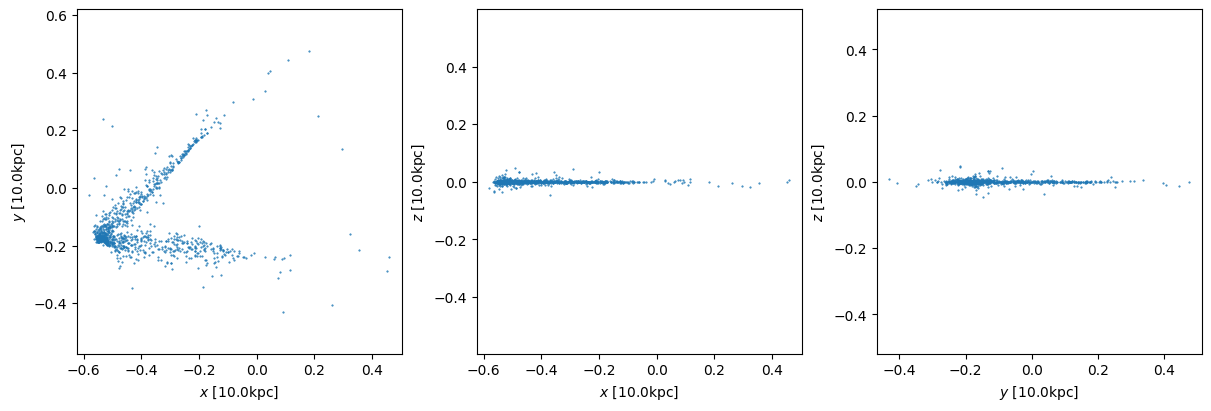

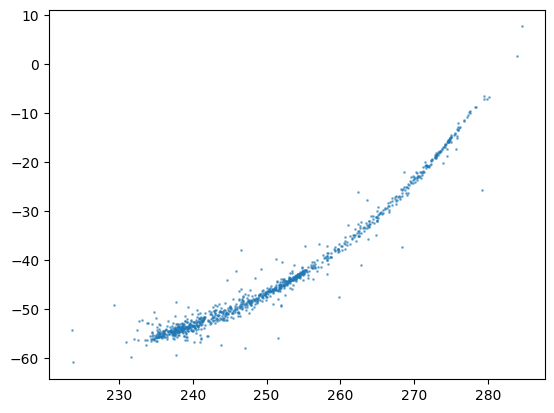

In [20]:
pot_a = gp.PlummerPotential(m=1,
                            b=1,
                            units=exp_units)

# Initialise simulation submodels
gen_object = ms.MockStreamGenerator(df=ms.ChenStreamDF(lead=True, trail=True), # stream distribution function 
                                    hamiltonian=pot_a, # potential within which the stream is disrupted
                                    progenitor_potential=gc_pot 
                                    )
start = time.time()
stream_obj, _ = gen_object.run(prog_w0=gc_w0, # initial (or final) phase-space position of the progenitor system
                               prog_mass=gc_mass, # sets the scale mass of the particle release
                               release_every=1, # how many times particles are released at each time step
                               n_particles=1, # how many particles are released by the trail and the lead of the stream each time. Can be an array with same lenth as the timesteps,
                               t1=t1,
                               t2=t2,
                               n_steps = n_steps,
                               Integrator=gi.LeapfrogIntegrator,
                               )  
print(f"Simulation done in {time.time()-start} seconds")

xyz = stream_obj.xyz.to(u.kpc)

_ = stream_obj.plot(s=1)

import astropy.coordinates as coord

stream_obj_obs = stream_obj.to_coord_frame(coord.ICRS())
fig,ax = plt.subplots()
ax.scatter(stream_obj_obs.ra.value,
           stream_obj_obs.dec.value,
           s=1,
           alpha=0.5)

In [21]:
orbit = pot_a.integrate_orbit(gc_w0, t1=t1, t2=t2, n_steps=10000)

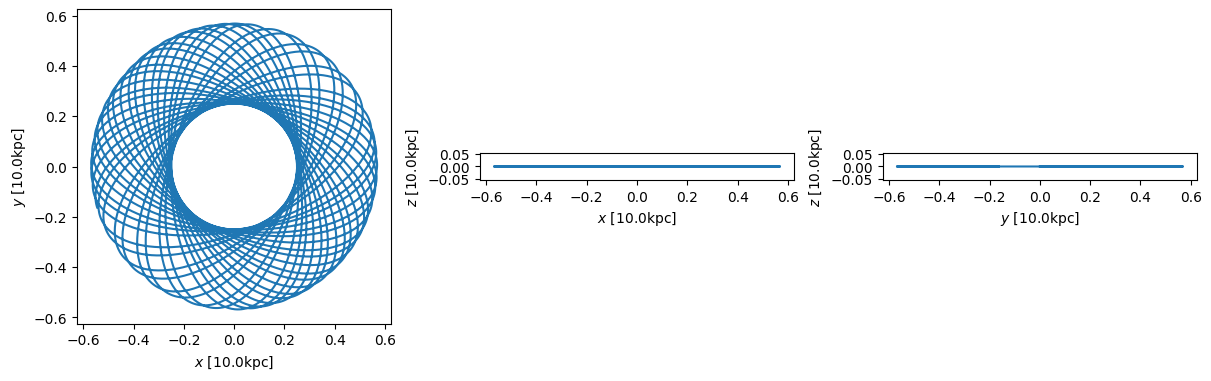

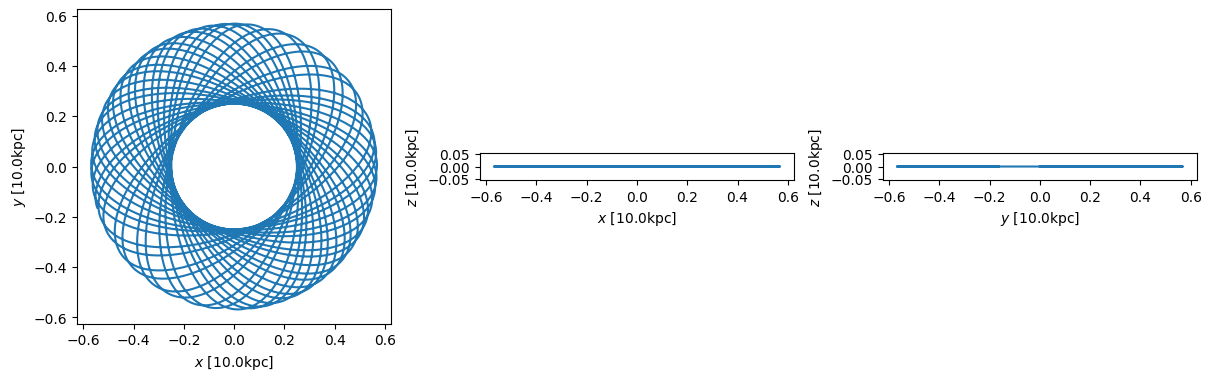

In [22]:
orbit.plot()

In [23]:
orbit = pot.integrate_orbit(gc_w0, t1=t1, t2=t2, n_steps=10000)

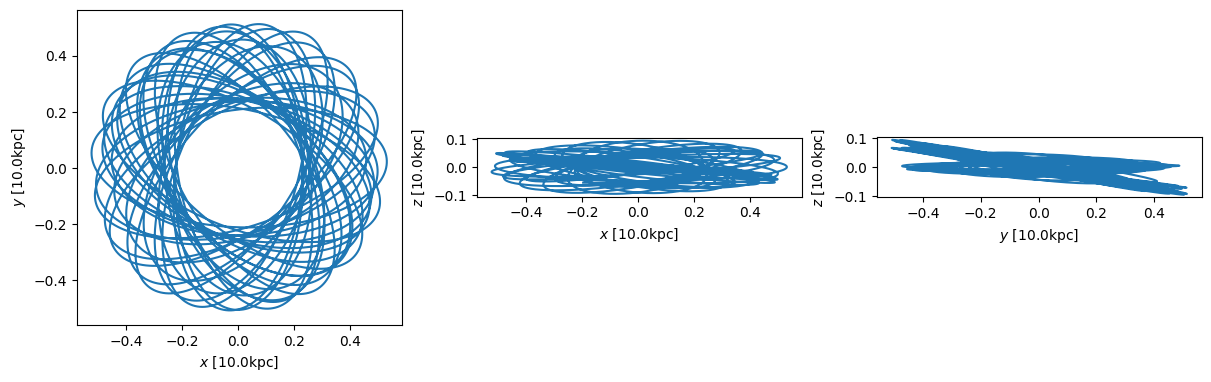

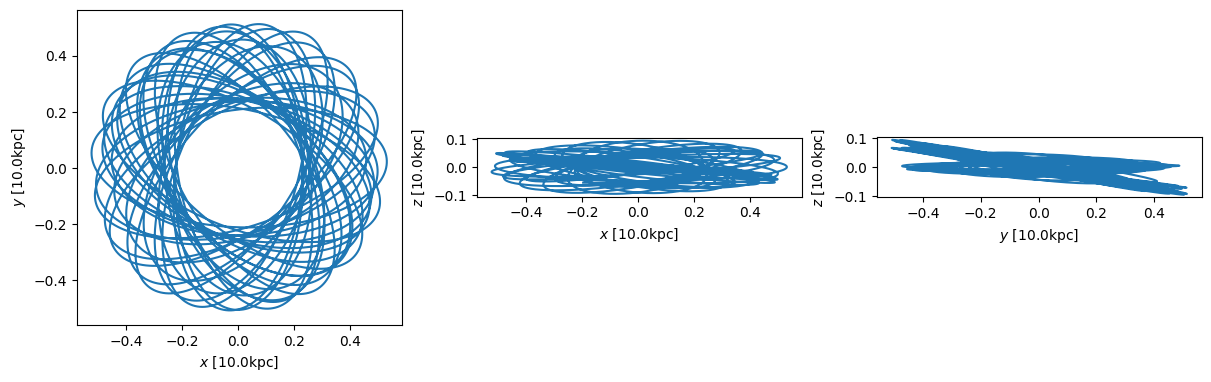

In [24]:
orbit.plot()

In [ ]:
# What time spacing do we need?
# When do we truncate the expansion to avoid incorporating too much noise?

# Investigate the effect of snapshots time cadence to the approximation of the potential

In [1]:
from gala.units import SimulationUnitSystem, DimensionlessUnitSystem
import gala.potential as gp
import gala.dynamics as gd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import os
import pyEXP
import DREAMS_utils
import yaml
import pynbody
import astropy.units as u

x0 = np.array([0.5, 0.5, 0])
v0 = np.array([0., 0.25, 0])

#print(f"Simulating GC disruption at x0={x0.to(u.kpc)} and v0={v0.to(u.km/u.s)}")
gc_w0 = gd.PhaseSpacePosition(pos=x0,
                              vel=v0)

pot_a = gp.PlummerPotential(m=1,
                            b=1,
                            units=DimensionlessUnitSystem())



### Radial Period vs Azimuthal Period

In [2]:
def get_radial_and_azimuthal_periods(ps_ics):
    
    orbit = pot_a.integrate_orbit(ps_ics, t1=0, t2=1000, n_steps=10000)

    # Get pericenter times
    _,t_peri =orbit.pericenter(func=None,return_times=True)

    # Define radial period to be the time the particles goes "peri-apo-peri" 
    radial_period = t_peri[1] - t_peri[0]

    idx_peri0 = np.argmin((orbit.t-t_peri[0])**2)
    idx_peri1 = np.argmin((orbit.t-t_peri[1])**2)

    # Get the difference in the polar angle in the orbital plane after one radial period
    phi1 = np.arctan(orbit.y[idx_peri0]/orbit.x[idx_peri0])
    phi2 = np.arctan(orbit.y[idx_peri1]/orbit.x[idx_peri1])

    delta_phi = np.abs(phi2 - phi1)

    azimuthal_period = (2*np.pi / delta_phi.value) * radial_period
    
    return radial_period, azimuthal_period

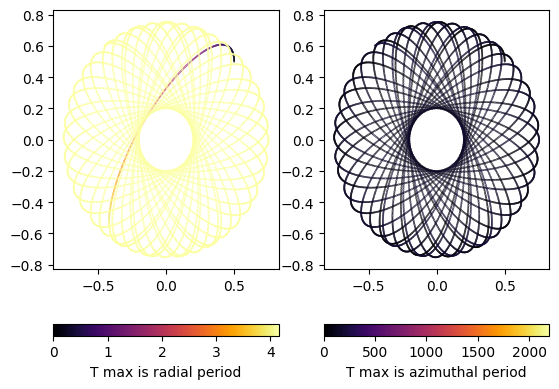

In [3]:
orbit = pot_a.integrate_orbit(gc_w0, t1=0, t2=200, n_steps=10000)
radial_period, azimuthal_period = get_radial_and_azimuthal_periods(gc_w0)

fig,axs = plt.subplots(1,2)

cmap = mpl.colormaps["inferno"]

norm = mpl.colors.Normalize(vmin=0, vmax=radial_period)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
axs[0].scatter(orbit.x, orbit.y, c=sm.to_rgba(orbit.t), s=0.1)
cbar = fig.colorbar(sm,ax=axs[0], orientation="horizontal")
cbar.set_label("T max is radial period")

norm = mpl.colors.Normalize(vmin=0, vmax=azimuthal_period)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
axs[1].scatter(orbit.x, orbit.y, c=sm.to_rgba(orbit.t), s=0.1)
cbar = fig.colorbar(sm,ax=axs[1], orientation="horizontal")
cbar.set_label("T max is azimuthal period")


In [4]:

radial_period, azimuthal_period = get_radial_and_azimuthal_periods(gc_w0)

print(f"T radial: {radial_period:.1f}\nT azimuthal: {azimuthal_period:.1f}")

T radial: 4.2
T azimuthal: 2197.4


In [5]:
# Load data from sims
output_dir = "/mnt/home/asante/ceph/PlummerNbody/N6/"
outputs = os.listdir(output_dir)
outputs = [o for o in outputs if ".npz" in o]
# Order files by snapshot
t_outputs = sorted([0.01*float(out.replace("Plummer_outs_t","").replace(".npz","")) for out in outputs])
outputs = [f"Plummer_outs_t{int(t):03}.npz" for t in t_outputs]

lims = 10

# Load position, velocity, and masses of particles at last snapshot
data_final = np.load(f"{output_dir}{outputs[-1]}", allow_pickle=True)

In [2]:
def make_basis(lmax, nmax=20):
    
    # 1 - Calculate base density
    density_params_df = {"bins": 200,
                        "rangevals": [0.01,10]}

    rbins, dvals = DREAMS_utils.return_density(r=np.sqrt(np.sum(data_final["x"]**2,axis=1)), 
                                            weights=data_final["m"], 
                                            **density_params_df, 
                                            smooth=True)

    # Create BFE approximation of the potential
    # 2 - Set up basis
    # Create an EXP-compatible spherical basis function table 
    model_file = f"{output_dir}basis_empirical_PlummerTest.txt" 
    cache_file = model_file.replace(".txt",".cache.run0")

    # Check if model or table have already been computed
    if os.path.exists(model_file):
        os.remove(model_file)
    if os.path.exists(cache_file):
        os.remove(cache_file)

    rbins, dvals, mass, potential = DREAMS_utils.makemodel_empirical(rvals=rbins,
                                                                    dvals=dvals,
                                                                    pfile=model_file) 
    config = {"id" : "sphereSL",
                "parameters": {"numr": 1000,
                                "rmin": 0.01,
                                "rmax": 10,
                                "Lmax": lmax,
                                "nmax": nmax,
                                "rmapping": 0.1,
                                "modelname": model_file,
                                "cachename": model_file.replace(".txt",".cache.run0")
                                }
                }


    # Save yaml file for constructing gala potential
    yaml_file = f"{output_dir}basis_yaml_PlummerTest.yml"

    with open(yaml_file, "w") as f:
        yaml.dump(config, f, default_flow_style=False)
        
        
    # Construct basis
    with open(yaml_file, "r") as f:
        yaml_config = f.read()

    # Build the basis
    basis = pyEXP.basis.Basis.factory(yaml_config) 
    
    return basis, yaml_file

def get_coefs(radial_period, n_snaps_per_period, t_start=0):

    time_step_cadence = np.round(radial_period / n_snaps_per_period, decimals=2)

    idx_snapshots = [i for i in range(len(t_outputs)) if t_outputs[i] in np.arange(1000)*time_step_cadence]
    
    # Select only snapshots after a certain time, i.e. allow the system to relax
    idx_snapshots = [idx_snapshots[i] for i in range(len(idx_snapshots)) if t_outputs[idx_snapshots[i]]>=t_start]

    # 3 - Calculate coefficients
    coefs_container = None

    for idx in idx_snapshots:
        
        data_file = np.load(f"{output_dir}{outputs[idx]}")
        
        # Center
        sim = pynbody.new(dark=1000000)
        sim["pos"] = data_file["x"]
        sim["mass"] = data_file["m"]

        pynbody.analysis.center(sim, with_velocity=False)

        coefs = basis.createFromArray(sim["mass"],
                                    sim["pos"], 
                                    time=t_outputs[idx])
        
        if coefs_container is None:
            coefs_container = pyEXP.coefs.Coefs.makecoefs(coefs)
            coefs_container.add(coefs)
        else:
            coefs_container.add(coefs)
            
    # Save the coefficients
    coefs_file = f"{output_dir}coefs_PlummerTest.h5"
    if os.path.exists(coefs_file):
        os.remove(coefs_file)
        coefs_container.WriteH5Coefs(coefs_file) 
    else:
        coefs_container.WriteH5Coefs(coefs_file)
        
    return coefs_container, coefs_file


[0.0, 4.15, 8.3, 12.45, 16.6, 20.75, 24.9, 33.2, 37.35, 41.5, 49.8, 53.95, 66.4, 74.7, 78.85, 83.0, 87.15, 95.45, 99.6]
---- SLGridSph::ReadH5Cache: successfully read basis cache </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- Spherical::orthoTest: worst=0.0119681


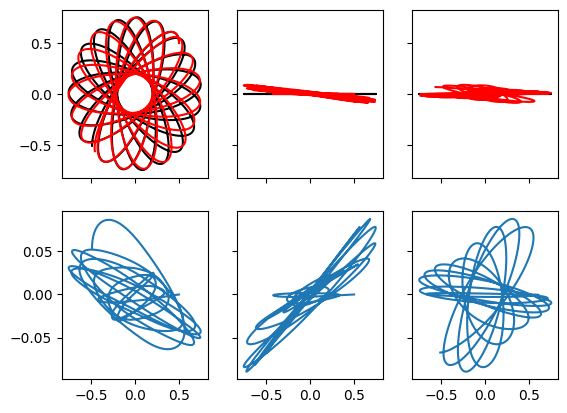

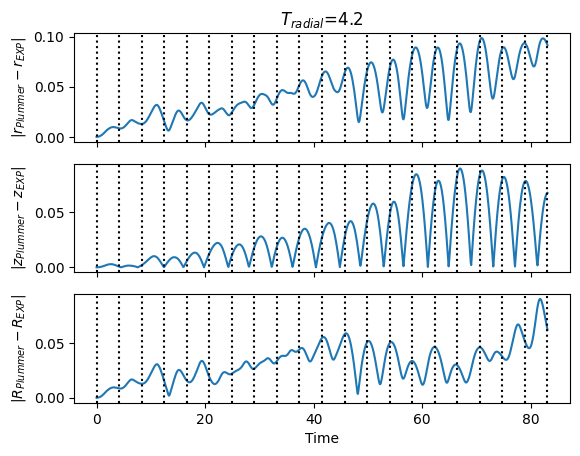

In [26]:
coefs, coefs_file = get_coefs(radial_period=radial_period, n_snaps_per_period=1, t_start=0)

print(coefs.Times())

exp_units = SimulationUnitSystem(mass=10**12*u.Msun, # Can decide here how big your system is
                                 length=10*u.kpc, # Specify what's the scale radius
                                 G=1)

pot = gp.EXPPotential(units=exp_units,
                      config_file=yaml_file,
                      coef_file=coefs_file)

pot_a = gp.PlummerPotential(m=1,
                            b=1,
                            units=exp_units)


t1 = 0
t2 = 20*radial_period#min(20*radial_period,100)


fig,axs = plt.subplots(2,3, sharex=True, sharey="row")
orbit_a = pot_a.integrate_orbit(gc_w0, t1=t1, t2=t2, n_steps=1000)
orbit_exp = pot.integrate_orbit(gc_w0, t1=t1, t2=t2, n_steps=1000)

axs[0,0].plot(orbit_a.x, orbit_a.y, c="k", label="Plummer")
axs[0,0].plot(orbit_exp.x, orbit_exp.y, c="r", label="EXP")
axs[0,1].plot(orbit_a.x, orbit_a.z, c="k")
axs[0,1].plot(orbit_exp.x, orbit_exp.z, c="r")
axs[0,2].plot(orbit_a.y, orbit_a.z, c="k")
axs[0,2].plot(orbit_exp.y, orbit_exp.z, c="r")



axs[1,0].plot(orbit_a.x, orbit_a.y - orbit_exp.y)
axs[1,1].plot(orbit_a.x, orbit_a.z - orbit_exp.z)
axs[1,2].plot(orbit_a.y, orbit_a.z - orbit_exp.z)

delta_r = np.sqrt(np.sum((orbit_a.xyz - orbit_exp.xyz)**2,axis=0))
delta_R = np.sqrt(np.sum((np.vstack([orbit_a.x,orbit_a.y]) - np.vstack([orbit_exp.x,orbit_exp.y]))**2,axis=0))

fig,axs = plt.subplots(3,1, sharex=True)
axs[0].plot(orbit_a.t, delta_r)
axs[1].plot(orbit_a.t, np.abs(orbit_a.z-orbit_exp.z))
axs[2].plot(orbit_a.t, delta_R)
axs[0].set_ylabel("$|r_{Plummer}-r_{EXP}|$")
axs[1].set_ylabel("$|z_{Plummer}-z_{EXP}|$")
axs[2].set_ylabel("$|R_{Plummer}-R_{EXP}|$")
axs[2].set_xlabel("Time")
axs[0].set_title("$T_{radial}$="+f"{radial_period:.1f}")
for t in [radial_period*i for i in range(int(max(orbit_a.t.value)//radial_period)+1)]:
    axs[0].axvline(x=t, c="k", ls=":")
    axs[1].axvline(x=t, c="k", ls=":")
    axs[2].axvline(x=t, c="k", ls=":")

[53.95, 66.4, 74.7, 78.85, 83.0, 87.15, 95.45, 99.6]
---- SLGridSph::ReadH5Cache: successfully read basis cache </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- Spherical::orthoTest: worst=0.0119681


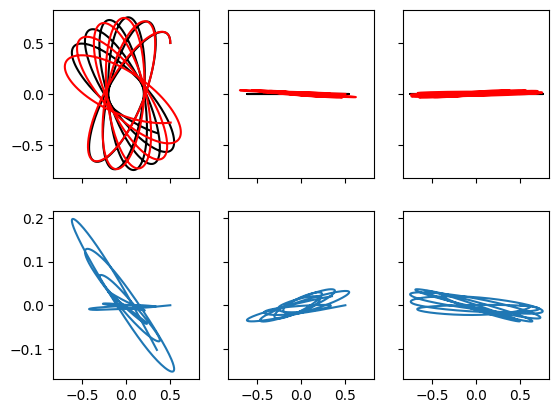

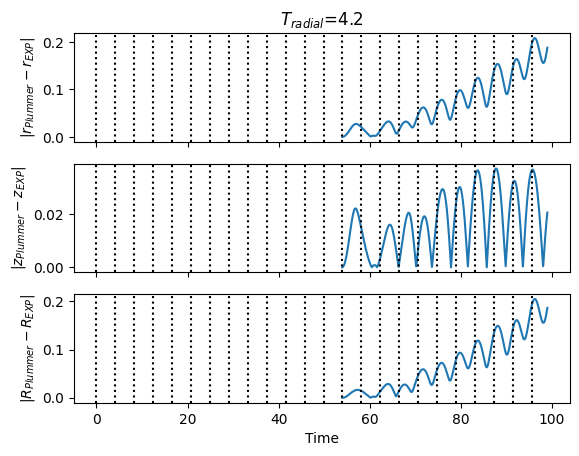

In [22]:
coefs, coefs_file = get_coefs(radial_period=radial_period, n_snaps_per_period=1, t_start=50)

print(coefs.Times())

exp_units = SimulationUnitSystem(mass=10**12*u.Msun, # Can decide here how big your system is
                                 length=10*u.kpc, # Specify what's the scale radius
                                 G=1)

pot = gp.EXPPotential(units=exp_units,
                      config_file=yaml_file,
                      coef_file=coefs_file)

pot_a = gp.PlummerPotential(m=1,
                            b=1,
                            units=exp_units)

t1 = coefs.Times()[0]
t2 = 99#min(20*radial_period,100)


fig,axs = plt.subplots(2,3, sharex=True, sharey="row")
orbit_a = pot_a.integrate_orbit(gc_w0, t1=t1, t2=t2, n_steps=1000)
orbit_exp = pot.integrate_orbit(gc_w0, t1=t1, t2=t2, n_steps=1000)

axs[0,0].plot(orbit_a.x, orbit_a.y, c="k", label="Plummer")
axs[0,0].plot(orbit_exp.x, orbit_exp.y, c="r", label="EXP")
axs[0,1].plot(orbit_a.x, orbit_a.z, c="k")
axs[0,1].plot(orbit_exp.x, orbit_exp.z, c="r")
axs[0,2].plot(orbit_a.y, orbit_a.z, c="k")
axs[0,2].plot(orbit_exp.y, orbit_exp.z, c="r")



axs[1,0].plot(orbit_a.x, orbit_a.y - orbit_exp.y)
axs[1,1].plot(orbit_a.x, orbit_a.z - orbit_exp.z)
axs[1,2].plot(orbit_a.y, orbit_a.z - orbit_exp.z)

delta_r = np.sqrt(np.sum((orbit_a.xyz - orbit_exp.xyz)**2,axis=0))
delta_R = np.sqrt(np.sum((np.vstack([orbit_a.x,orbit_a.y]) - np.vstack([orbit_exp.x,orbit_exp.y]))**2,axis=0))

fig,axs = plt.subplots(3,1, sharex=True)
axs[0].plot(orbit_a.t, delta_r)
axs[1].plot(orbit_a.t, np.abs(orbit_a.z-orbit_exp.z))
axs[2].plot(orbit_a.t, delta_R)
axs[0].set_ylabel("$|r_{Plummer}-r_{EXP}|$")
axs[1].set_ylabel("$|z_{Plummer}-z_{EXP}|$")
axs[2].set_ylabel("$|R_{Plummer}-R_{EXP}|$")
axs[2].set_xlabel("Time")
axs[0].set_title("$T_{radial}$="+f"{radial_period:.1f}")
for t in [radial_period*i for i in range(int(max(orbit_a.t.value)//radial_period)+1)]:
    axs[0].axvline(x=t, c="k", ls=":")
    axs[1].axvline(x=t, c="k", ls=":")
    axs[2].axvline(x=t, c="k", ls=":")


! Scaling:  R= 9.827935816415723   M= 1.0
1.0 0.9685124831368517 0.9685124831368516 0.9685124831368516
---- SLGridSph::WriteH5Cache: wrote </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- Spherical::orthoTest: worst=0.00856634


---- SLGridSph::ReadH5Cache: error reading </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- SLGridSph::ReadH5Cache: HDF5 error is <Unable to open file /mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0 (File accessibility) Unable to open file>


[0.0, 4.15, 8.3, 12.45, 16.6, 20.75, 24.9, 33.2, 37.35, 41.5, 49.8, 53.95, 66.4, 74.7, 78.85, 83.0, 87.15, 95.45, 99.6]
---- SLGridSph::ReadH5Cache: successfully read basis cache </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- Spherical::orthoTest: worst=0.00856634


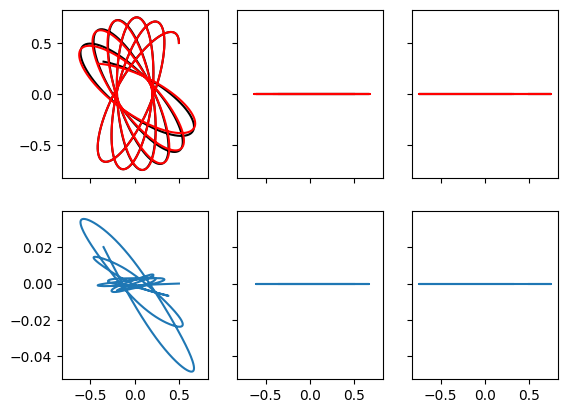

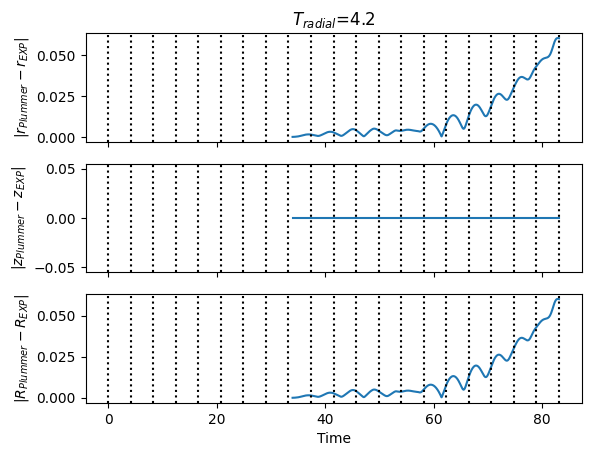

In [18]:
basis = make_basis(lmax=0)

coefs, coefs_file = get_coefs(radial_period=radial_period, n_snaps_per_period=1, t_start=0)

print(coefs.Times())

exp_units = SimulationUnitSystem(mass=10**12*u.Msun, # Can decide here how big your system is
                                 length=10*u.kpc, # Specify what's the scale radius
                                 G=1)

pot = gp.EXPPotential(units=exp_units,
                      config_file=yaml_file,
                      coef_file=coefs_file)

pot_a = gp.PlummerPotential(m=1,
                            b=1,
                            units=exp_units)

t1 = 34
t2 = min(20*radial_period,100)


fig,axs = plt.subplots(2,3, sharex=True, sharey="row")
orbit_a = pot_a.integrate_orbit(gc_w0, t1=t1, t2=t2, n_steps=1000)
orbit_exp = pot.integrate_orbit(gc_w0, t1=t1, t2=t2, n_steps=1000)

axs[0,0].plot(orbit_a.x, orbit_a.y, c="k", label="Plummer")
axs[0,0].plot(orbit_exp.x, orbit_exp.y, c="r", label="EXP")
axs[0,1].plot(orbit_a.x, orbit_a.z, c="k")
axs[0,1].plot(orbit_exp.x, orbit_exp.z, c="r")
axs[0,2].plot(orbit_a.y, orbit_a.z, c="k")
axs[0,2].plot(orbit_exp.y, orbit_exp.z, c="r")



axs[1,0].plot(orbit_a.x, orbit_a.y - orbit_exp.y)
axs[1,1].plot(orbit_a.x, orbit_a.z - orbit_exp.z)
axs[1,2].plot(orbit_a.y, orbit_a.z - orbit_exp.z)

delta_r = np.sqrt(np.sum((orbit_a.xyz - orbit_exp.xyz)**2,axis=0))
delta_R = np.sqrt(np.sum((np.vstack([orbit_a.x,orbit_a.y]) - np.vstack([orbit_exp.x,orbit_exp.y]))**2,axis=0))

fig,axs = plt.subplots(3,1, sharex=True)
axs[0].plot(orbit_a.t, delta_r)
axs[1].plot(orbit_a.t, np.abs(orbit_a.z-orbit_exp.z))
axs[2].plot(orbit_a.t, delta_R)
axs[0].set_ylabel("$|r_{Plummer}-r_{EXP}|$")
axs[1].set_ylabel("$|z_{Plummer}-z_{EXP}|$")
axs[2].set_ylabel("$|R_{Plummer}-R_{EXP}|$")
axs[2].set_xlabel("Time")
axs[0].set_title("$T_{radial}$="+f"{radial_period:.1f}")
for t in [radial_period*i for i in range(int(max(orbit_a.t.value)//radial_period)+1)]:
    axs[0].axvline(x=t, c="k", ls=":")
    axs[1].axvline(x=t, c="k", ls=":")
    axs[2].axvline(x=t, c="k", ls=":")


## Measure tilt of the plane as a function of the order of the expansion

In [1]:
from gala.units import SimulationUnitSystem, DimensionlessUnitSystem
import gala.potential as gp
import gala.dynamics as gd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import os
import pyEXP
import DREAMS_utils
import yaml
import pynbody
import astropy.units as u

x0 = np.array([0.5, 0.5, 0])
v0 = np.array([0., 0.25, 0])

#print(f"Simulating GC disruption at x0={x0.to(u.kpc)} and v0={v0.to(u.km/u.s)}")
gc_w0 = gd.PhaseSpacePosition(pos=x0,
                              vel=v0)

In [2]:
def make_basis(lmax, nmax=20):
    
    # 1 - Calculate base density
    density_params_df = {"bins": 200,
                        "rangevals": [0.01,10]}

    rbins, dvals = DREAMS_utils.return_density(r=np.sqrt(np.sum(data_final["x"]**2,axis=1)), 
                                            weights=data_final["m"], 
                                            **density_params_df, 
                                            smooth=True)

    # Create BFE approximation of the potential
    # 2 - Set up basis
    # Create an EXP-compatible spherical basis function table 
    model_file = f"{output_dir}basis_empirical_PlummerTest.txt" 
    cache_file = model_file.replace(".txt",".cache.run0")

    # Check if model or table have already been computed
    if os.path.exists(model_file):
        os.remove(model_file)
    if os.path.exists(cache_file):
        os.remove(cache_file)

    rbins, dvals, mass, potential = DREAMS_utils.makemodel_empirical(rvals=rbins,
                                                                    dvals=dvals,
                                                                    pfile=model_file) 
    config = {"id" : "sphereSL",
                "parameters": {"numr": 1000,
                                "rmin": 0.01,
                                "rmax": 10,
                                "Lmax": lmax,
                                "nmax": nmax,
                                "rmapping": 0.1,
                                "modelname": model_file,
                                "cachename": model_file.replace(".txt",".cache.run0")
                                }
                }


    # Save yaml file for constructing gala potential
    yaml_file = f"{output_dir}basis_yaml_PlummerTest.yml"

    with open(yaml_file, "w") as f:
        yaml.dump(config, f, default_flow_style=False)
        
        
    # Construct basis
    with open(yaml_file, "r") as f:
        yaml_config = f.read()

    # Build the basis
    basis = pyEXP.basis.Basis.factory(yaml_config) 
    
    return basis, yaml_file

def get_coefs(radial_period, n_snaps_per_period, t_start=0):

    time_step_cadence = np.round(radial_period / n_snaps_per_period, decimals=2)

    idx_snapshots = [i for i in range(len(t_outputs)) if t_outputs[i] in np.arange(1000)*time_step_cadence]
    
    # Select only snapshots after a certain time, i.e. allow the system to relax
    idx_snapshots = [idx_snapshots[i] for i in range(len(idx_snapshots)) if t_outputs[idx_snapshots[i]]>=t_start]

    # 3 - Calculate coefficients
    coefs_container = None

    for idx in idx_snapshots:
        
        data_file = np.load(f"{output_dir}{outputs[idx]}")
        
        # Center
        sim = pynbody.new(dark=1000000)
        sim["pos"] = data_file["x"]
        sim["mass"] = data_file["m"]

        pynbody.analysis.center(sim, with_velocity=False)

        coefs = basis.createFromArray(sim["mass"],
                                    sim["pos"], 
                                    time=t_outputs[idx])
        
        if coefs_container is None:
            coefs_container = pyEXP.coefs.Coefs.makecoefs(coefs)
            coefs_container.add(coefs)
        else:
            coefs_container.add(coefs)
            
    # Save the coefficients
    coefs_file = f"{output_dir}coefs_PlummerTest.h5"
    if os.path.exists(coefs_file):
        os.remove(coefs_file)
        coefs_container.WriteH5Coefs(coefs_file) 
    else:
        coefs_container.WriteH5Coefs(coefs_file)
        
    return coefs_container, coefs_file


In [3]:
basis, yaml_file = make_basis(lmax=6, nmax=20)
coefs, coefs_file = get_coefs(radial_period=1, n_snaps_per_period=1, t_start=0)

print(coefs.Times())

exp_units = SimulationUnitSystem(mass=10**12*u.Msun, # Can decide here how big your system is
                                 length=10*u.kpc, # Specify what's the scale radius
                                 G=1)

pot = gp.EXPPotential(units=exp_units,
                      config_file=yaml_file,
                      coef_file=coefs_file)

pot_a = gp.PlummerPotential(m=1,
                            b=1,
                            units=exp_units)

t1 = coefs.Times()[0]
t2 = coefs.Times()[-1]


fig,axs = plt.subplots(2,3, sharex=True, sharey="row")
orbit_a = pot_a.integrate_orbit(gc_w0, t1=t1, t2=t2, n_steps=1000)
orbit_exp = pot.integrate_orbit(gc_w0, t1=t1, t2=t2, n_steps=1000)

# Measure mean tilt


NameError: name 'data_final' is not defined

# Studying the number of coefficients

In [1]:
from gala.units import SimulationUnitSystem, DimensionlessUnitSystem
import gala.potential as gp
import gala.dynamics as gd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import os
import pyEXP
import DREAMS_utils
import yaml
import pynbody
import astropy.units as u

x0 = np.array([0.5, 0.5, 0])
v0 = np.array([0., 0.25, 0])

# Load data from sims
output_dir = "/mnt/home/asante/ceph/PlummerNbody/N6/"
outputs = os.listdir(output_dir)
outputs = [o for o in outputs if ".npz" in o]
# Order files by snapshot
t_outputs = sorted([0.01*float(out.replace("Plummer_outs_t","").replace(".npz","")) for out in outputs])
outputs = [f"Plummer_outs_t{int(t):03}.npz" for t in t_outputs]

data_final = np.load(f"{output_dir}{outputs[-1]}", allow_pickle=True)

In [2]:
comp = "sphereSL"
runtag = ""

# 1 - Calculate base density
density_params_df = {"bins": 200,
                     "rangevals": [0.01,10]}

rbins, dvals = DREAMS_utils.return_density(r=np.sqrt(np.sum(data_final["x"]**2,axis=1)), 
                                           weights=data_final["m"], 
                                           **density_params_df, 
                                           smooth=True)

# Create BFE approximation of the potential
# 2 - Set up basis
# Create an EXP-compatible spherical basis function table 
model_file = f"{output_dir}basis_empirical_PlummerTest.txt" 
cache_file = model_file.replace(".txt",f".cache.{runtag}")

# Check if model or table have already been computed
if os.path.exists(model_file):
    os.remove(model_file)
if os.path.exists(cache_file):
    os.remove(cache_file)

rbins, dvals, mass, potential = DREAMS_utils.makemodel_empirical(rvals=rbins,
                                                                 dvals=dvals,
                                                                 pfile=model_file) 
config = {"id" : comp,
          "parameters": {"numr": 1000,
                            "rmin": 0.01,
                            "rmax": 10,
                            "Lmax": 6,
                            "nmax": 20,
                            "rmapping": 0.1,
                            "modelname": model_file,
                            "cachename": cache_file,
                            "pcavar": True,
                            "subsamp": 1
                            },
          "runtag": runtag
            }


# Save yaml file for constructing gala potential
yaml_file = f"{output_dir}basis_yaml_PlummerTest.yml"

with open(yaml_file, "w") as f:
    yaml.dump(config, f, default_flow_style=False)
    
    
# Construct basis
with open(yaml_file, "r") as f:
    yaml_config = f.read()

# Build the basis
basis = pyEXP.basis.Basis.factory(yaml_config) 


! Scaling:  R= 9.827935816415723   M= 1.0
1.0 0.9685124831368517 0.9685124831368516 0.9685124831368516
---- SLGridSph::WriteH5Cache: wrote </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- Spherical::orthoTest: worst=0.0119681


---- SLGridSph::ReadH5Cache: error reading </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- SLGridSph::ReadH5Cache: HDF5 error is <Unable to open file /mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0 (File accessibility) Unable to open file>


In [3]:
# Read the covariance 
covar = pyEXP.basis.CovarianceReader('coefcovar.{}.{}.h5'.format(comp, runtag))
coefs = pyEXP.coefs.Coefs.factory("/mnt/home/asante/ceph/PlummerNbody/N6/coefs_PlummerTest.h5")

HDF5-DIAG: Error detected in HDF5 (1.12.3) thread 0:
  #000: /dev/shm/nix-build-hdf5-1.12.3.drv-1/nixbld1/spack-stage-hdf5-1.12.3-fx4s301kfywhjkdqaldc721gdabrlwkz/spack-src/src/H5F.c line 619 in H5Fopen(): unable to open file
    major: File accessibility
    minor: Unable to open file
  #001: /dev/shm/nix-build-hdf5-1.12.3.drv-1/nixbld1/spack-stage-hdf5-1.12.3-fx4s301kfywhjkdqaldc721gdabrlwkz/spack-src/src/H5VLcallback.c line 3522 in H5VL_file_open(): open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: /dev/shm/nix-build-hdf5-1.12.3.drv-1/nixbld1/spack-stage-hdf5-1.12.3-fx4s301kfywhjkdqaldc721gdabrlwkz/spack-src/src/H5VLcallback.c line 3351 in H5VL__file_open(): open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: /dev/shm/nix-build-hdf5-1.12.3.drv-1/nixbld1/spack-stage-hdf5-1.12.3-fx4s301kfywhjkdqaldc721gdabrlwkz/spack-src/src/H5VLnative_file.c line 97 in H5VL__native_file_open(): unable to open file
    major: File accessibili

In [35]:
# Get coefficients values [spherical_index, radial_index, time_index]
# spherical_index = l*(l+1)/2 + m

coefs_values = coefs.getAllCoefs()

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt

l = 0
m = 0

def plot_coefs_evolution(coefs, 
                         l, 
                         m,
                         ax):
    
    coefs_values = coefs.getAllCoefs()
    times = coefs.Times()
    
    spherical_index = (l * (l + 1)) // 2 + m
    n_radial_terms = coefs_values.shape[1]

    cmap = mpl.colormaps["inferno"]
    norm = mpl.colors.Normalize(vmin=0, vmax=n_radial_terms)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    for n_radial in range(n_radial_terms):
        ax.plot(times, 
                coefs_values[spherical_index, n_radial, :],
                c=cmap(norm(n_radial)))
        
    ax.set_yscale("log")
    ax.set_ylabel("Coefficients amplitude")
    ax.set_xlabel("Time")

    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("Radial order")

    ax.set_title(f"l={l}, m={m}")
    return ax


<Axes: title={'center': 'l=2, m=0'}, xlabel='Time', ylabel='Coefficients amplitude'>

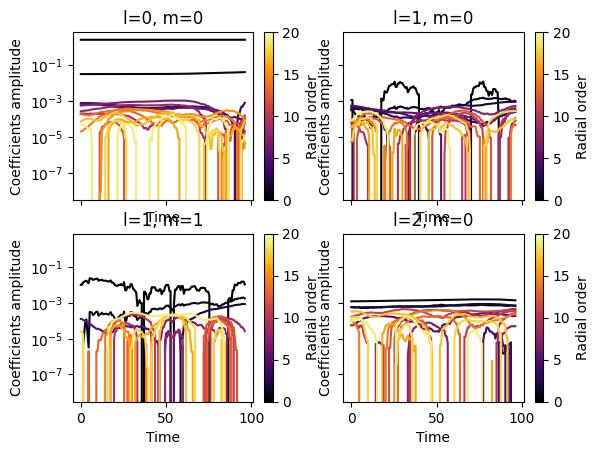

In [59]:
fig,axs = plt.subplots(2,2, sharex=True, sharey=True)
plot_coefs_evolution(coefs, l=0, m=0, ax=axs[0,0])
plot_coefs_evolution(coefs, l=1, m=0, ax=axs[0,1])
plot_coefs_evolution(coefs, l=1, m=1, ax=axs[1,0])
plot_coefs_evolution(coefs, l=2, m=0, ax=axs[1,1])

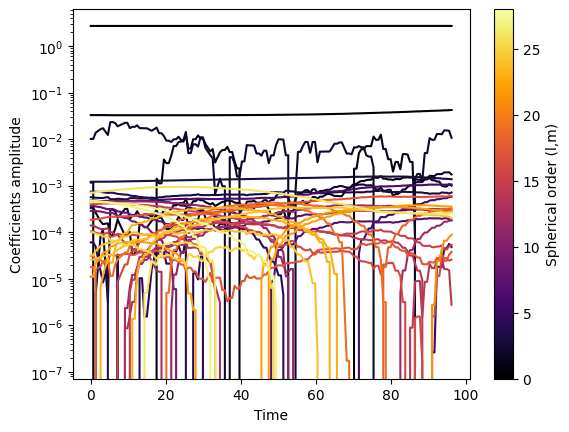

In [57]:
# In general, it seems the first radial terms dominate the power

fig,ax = plt.subplots()
coefs_values = coefs.getAllCoefs()
times = coefs.Times()

cmap = mpl.colormaps["inferno"]
norm = mpl.colors.Normalize(vmin=0, vmax=coefs_values.shape[0])
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

for l in range(6+1):
    for m in range(l+1):
        spherical_index = (l * (l + 1)) // 2 + m

        # Plot just the first two radial terms
        for n_radial in range(2):
            ax.plot(times, 
                    coefs_values[spherical_index, n_radial, :],
                    c=cmap(norm(spherical_index)))
    
ax.set_yscale("log")
ax.set_ylabel("Coefficients amplitude")
ax.set_xlabel("Time")

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Spherical order (l,m)")

### Covariance matrix analysis

Text(0.5, 1.0, 'l=0,m=0,t=100')

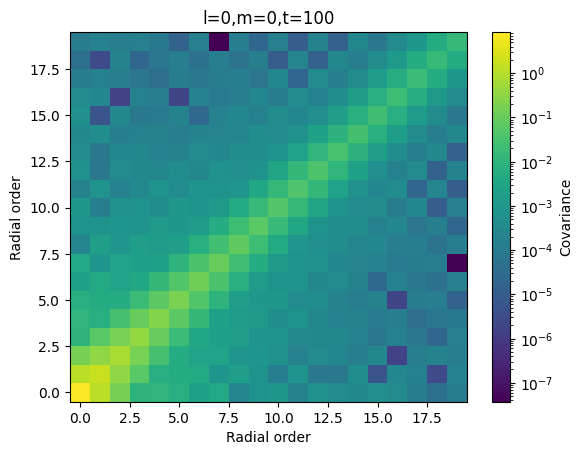

In [6]:
time = 100

# Get the values and covariance of the coefficients for the basis at time t
# output is a list where each element refers to a given spherical orders
outs = covar.getCoefCovariance(time)[0] 

l = 0
m = 0
spherical_index = (l * (l + 1)) // 2 + m

values, total_variance = outs[spherical_index]

n_radial_terms = len(values)

x = np.arange(0, n_radial_terms)
y = np.arange(0, n_radial_terms)
X, Y = np.meshgrid(x, y)

fig,ax = plt.subplots()
plot = ax.pcolormesh(X,Y,np.abs(total_variance), norm="log")

ax.set_xlabel("Radial order")
ax.set_ylabel("Radial order")

cbar = fig.colorbar(plot,ax=ax)
cbar.set_label("Covariance")

ax.set_title(f"l={l},m={m},t={time}")

In [55]:
def get_SNR(covar, time, l, m):
    """
    Returns the signal-to-noise (SNR, i.e. amplitude to variance) ratio for the coefficients 
    of the basis functions for all the radial orders associated to the given m and l 
    orders at a given time. 

    Args:
        covar (CovarianceReader): pyEXP object containing information on the coefficients
                                  values and covariance matrix at the given time
        time (float): time at which the coefficients are evaluated
        l (int): degree of the angular function in the expansion
        m (int): modes of l

    Returns:
        ndarray: array of the SNR for each radial mode at the specified angular mode
    """
    
    # Get the values and covariance of the coefficients for the basis at time t
    # output is a list where each element refers to a given spherical orders
    outs = covar.getCoefCovariance(time)[0] 
    
    # Define the index of the coefficients and covariance basis in the outputs
    spherical_index = (l * (l + 1)) // 2 + m

    coef_values, total_variance = outs[spherical_index]
    
    # Get the number of particles and mass for the particles (assumes subsample=1)
    N_particles, Mass_system = covar.getCovarSamples(time)
    
    # Weight coefs values by the total mass of the system
    coef_values_weighted = coef_values / Mass_system
    
    # Substract the variance associated to the coefficient values from the total variance
    variance_amplitudes = np.outer(coef_values_weighted, coef_values_weighted.conj())
    variance_noise = total_variance - variance_amplitudes
    
    # Calculate signal-to-noise ratio
    SNR = np.abs(coef_values)**2  / np.abs(np.diag(variance_noise))
    
    return SNR
    

NameError: name 'coefs' is not defined

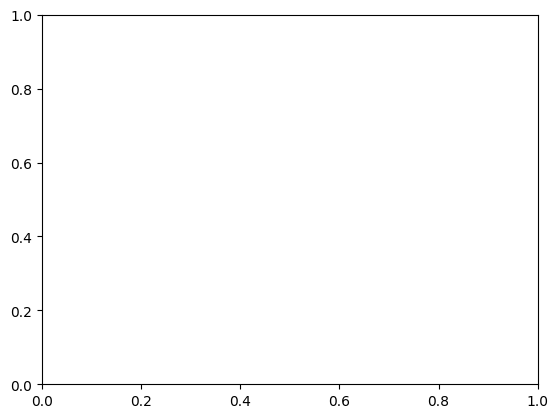

In [5]:
fig,ax = plt.subplots()

times = coefs.Times()

cmap = mpl.colormaps["inferno"]
norm = mpl.colors.Normalize(vmin=0, vmax=20)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

for l in range(6+1):
    for m in range(l+1):
        spherical_index = (l * (l + 1)) // 2 + m

        # Plot just the first two radial terms
        for n_radial in range(2):
            ax.plot(times, 
                    coefs_values[spherical_index, n_radial, :],
                    c=cmap(norm(spherical_index)))
    
ax.set_yscale("log")
ax.set_ylabel("Coefficients amplitude")
ax.set_xlabel("Time")

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Spherical order (l,m)")

In [ ]:
n_angular_modes = len(covar.getCoefCovariance(time)[0])

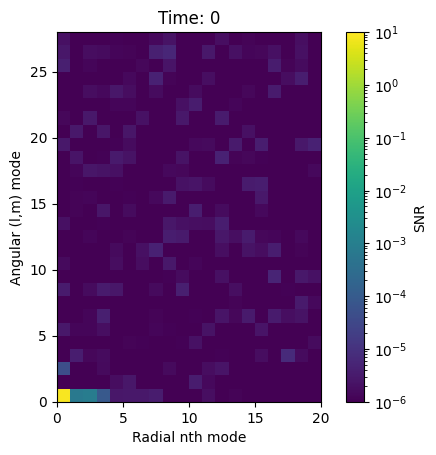

In [64]:
from matplotlib.animation import FuncAnimation

lmax = 6

vmin = 1e-6
vmax = 10

# Make plot at t=0
SNR_mesh = []

for l in range(lmax+1):
    for m in range(l+1):
        SNR_ml = get_SNR(covar=covar, time=0, l=l, m=m)
        SNR_mesh.append(SNR_ml)

SNR_mesh = np.vstack(SNR_mesh)

fig,ax = plt.subplots()
plot = ax.pcolormesh(SNR_mesh, norm="log", vmin=vmin, vmax=vmax)
cbar = fig.colorbar(plot,ax=ax)
cbar.set_label("SNR")

ax.set_xlabel("Radial nth mode")
ax.set_ylabel("Angular (l,m) mode")
ax.set_aspect(1)
ax.set_title(f"Time: {t}")

def update_SNR_frame(frame_time):
    
    SNR_mesh = []

    for l in range(lmax+1):
        for m in range(l+1):
            SNR_ml = get_SNR(covar=covar, time=frame_time, l=l, m=m)
            SNR_mesh.append(SNR_ml)

    SNR_mesh = np.vstack(SNR_mesh)
    
    plot.set_array(SNR_mesh.ravel())
    
    ax.set_title(f"Time: {frame_time}")

    return plot


anim = FuncAnimation(fig, update_SNR_frame, frames=[i for i in range(100)], blit=False)


In [66]:
anim.save('/mnt/home/asante/ceph/PlummerNbody/N6/snr_evolution.gif', writer='pillow', fps=4)

In [1]:
from gala.units import SimulationUnitSystem, DimensionlessUnitSystem
import gala.potential as gp
import gala.dynamics as gd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import os
import pyEXP
import DREAMS_utils
import yaml
import pynbody
import astropy.units as u

import numpy as np


rng = np.random.default_rng(16)

# Load data from sims
output_dir = "/mnt/home/asante/ceph/PlummerNbody/N6/"
outputs = os.listdir(output_dir)
outputs = [o for o in outputs if ".npz" in o]
# Order files by snapshot
t_outputs = sorted([0.01*float(out.replace("Plummer_outs_t","").replace(".npz","")) for out in outputs])
outputs = [f"Plummer_outs_t{int(t):03}.npz" for t in t_outputs]

data_final = np.load(f"{output_dir}{outputs[-1]}", allow_pickle=True)

In [2]:
def make_basis(lmax, nmax=20):
    
    # 1 - Calculate base density
    density_params_df = {"bins": 200,
                        "rangevals": [0.01,10]}

    rbins, dvals = DREAMS_utils.return_density(r=np.sqrt(np.sum(data_final["x"]**2,axis=1)), 
                                            weights=data_final["m"], 
                                            **density_params_df, 
                                            smooth=True)

    # Create BFE approximation of the potential
    # 2 - Set up basis
    # Create an EXP-compatible spherical basis function table 
    model_file = f"{output_dir}basis_empirical_PlummerTest.txt" 
    cache_file = model_file.replace(".txt",".cache.run0")

    # Check if model or table have already been computed
    if os.path.exists(model_file):
        os.remove(model_file)
    if os.path.exists(cache_file):
        os.remove(cache_file)

    rbins, dvals, mass, potential = DREAMS_utils.makemodel_empirical(rvals=rbins,
                                                                    dvals=dvals,
                                                                    pfile=model_file) 
    config = {"id" : "sphereSL",
                "parameters": {"numr": 1000,
                                "rmin": 0.01,
                                "rmax": 10,
                                "Lmax": lmax,
                                "nmax": nmax,
                                "rmapping": 0.1,
                                "modelname": model_file,
                                "cachename": model_file.replace(".txt",".cache.run0")
                                }
                }


    # Save yaml file for constructing gala potential
    yaml_file = f"{output_dir}basis_yaml_PlummerTest.yml"

    with open(yaml_file, "w") as f:
        yaml.dump(config, f, default_flow_style=False)
        
        
    # Construct basis
    with open(yaml_file, "r") as f:
        yaml_config = f.read()

    # Build the basis
    basis = pyEXP.basis.Basis.factory(yaml_config) 
    
    return basis, yaml_file

def get_coefs(radial_period, n_snaps_per_period, t_start=0):

    time_step_cadence = np.round(radial_period / n_snaps_per_period, decimals=2)

    idx_snapshots = [i for i in range(len(t_outputs)) if t_outputs[i] in np.arange(1000)*time_step_cadence]
    
    # Select only snapshots after a certain time, i.e. allow the system to relax
    idx_snapshots = [idx_snapshots[i] for i in range(len(idx_snapshots)) if t_outputs[idx_snapshots[i]]>=t_start]

    # 3 - Calculate coefficients
    coefs_container = None

    for idx in idx_snapshots:
        
        data_file = np.load(f"{output_dir}{outputs[idx]}")
        
        # Center
        sim = pynbody.new(dark=1000000)
        sim["pos"] = data_file["x"]
        sim["mass"] = data_file["m"]

        pynbody.analysis.center(sim, with_velocity=False)

        coefs = basis.createFromArray(sim["mass"],
                                    sim["pos"], 
                                    time=t_outputs[idx])
        
        if coefs_container is None:
            coefs_container = pyEXP.coefs.Coefs.makecoefs(coefs)
            coefs_container.add(coefs)
        else:
            coefs_container.add(coefs)
            
    # Save the coefficients
    coefs_file = f"{output_dir}coefs_PlummerTest.h5"
    if os.path.exists(coefs_file):
        os.remove(coefs_file)
        coefs_container.WriteH5Coefs(coefs_file) 
    else:
        coefs_container.WriteH5Coefs(coefs_file)
        
    return coefs_container, coefs_file


In [71]:
basis, yaml_file = make_basis(lmax=6, nmax=20)
coefs, coefs_file = get_coefs(radial_period=1, n_snaps_per_period=1, t_start=0)

print(coefs.Times())

exp_units = SimulationUnitSystem(mass=10**12*u.Msun, # Can decide here how big your system is
                                 length=10*u.kpc, # Specify what's the scale radius
                                 G=1)

pot = gp.EXPPotential(units=exp_units,
                      config_file=yaml_file,
                      coef_file=coefs_file)

pot_a = gp.PlummerPotential(m=1,
                            b=1,
                            units=exp_units)


! Scaling:  R= 9.827935816415723   M= 1.0
1.0 0.9685124831368517 0.9685124831368516 0.9685124831368516
---- SLGridSph::WriteH5Cache: wrote </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>


---- SLGridSph::ReadH5Cache: error reading </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- SLGridSph::ReadH5Cache: HDF5 error is <Unable to open file /mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0 (File accessibility) Unable to open file>


---- Spherical::orthoTest: worst=0.0119681
[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0, 85.0, 86.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0, 99.0]
---- SLGridSph::ReadH5Cache: successfully read basis cache </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- Spherical::orthoTest: worst=0.0119681


In [4]:
# Define test particles

x0 = rng.normal(loc=0, scale=1, size=(3,1000))
r = np.sqrt(np.sum(x0**2,axis=0))
# Define escape velocity
v_esc = np.sqrt(2/np.sqrt(r**2+1))
# Initialize velocity vectors at random
v0 = np.abs(rng.normal(loc=0, scale=1, size=(3,1000)))
# Get unit vectors
v0 /= np.sqrt(np.sum(v0**2,axis=0))
# Ensure velocities are less than the escape velocity
f_vesc = rng.uniform(high=0.9, size=1000)
v0 *= f_vesc


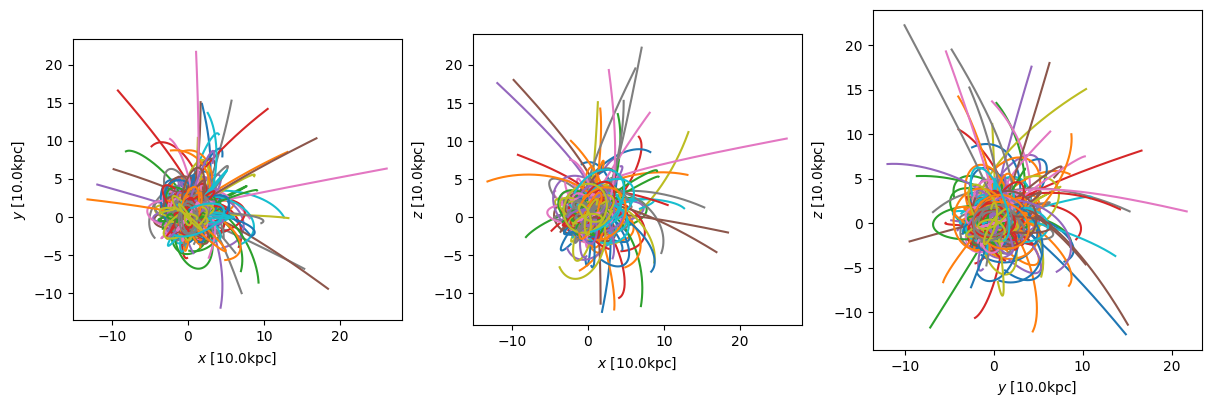

In [72]:
# Integrate orbits of test particles
orbits_ics = gd.PhaseSpacePosition(pos=x0,
                                   vel=v0)
orbits_a = pot_a.integrate_orbit(orbits_ics, t1=0, t2=50, n_steps=10000)
orbits_exp = pot.integrate_orbit(orbits_ics, t1=0, t2=50, n_steps=10000)
_=orbits_a.plot()

In [ ]:
import pandas as pd

def save_attrs_to_df(orbit):
    
    E = orbit.energy()
    peri = orbit.pericenter()
    apo = orbit.apocenter()
    ecc = orbit.eccentricity()
    L = orbit.angular_momentum()
    
    df = pd.DataFrame({"Ei": E[0],
                       "Ef": E[-1],
                       "peri": peri,
                       "apo": apo,
                       "e": ecc,
                       "Lxi": L[0,0,:],
                       "Lyi": L[1,0,:],
                       "Lzi": L[2,0,:],
                       "Lxf": L[0,-1,:],
                       "Lyf": L[1,-1,:],
                       "Lzf": L[2,-1,:]
                       })
    
    return df

In [73]:
df_a = save_attrs_to_df(orbits_a)
df_exp = save_attrs_to_df(orbits_exp)

/mnt/home/asante/streams_in_dreams/expgala/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/mnt/home/asante/streams_in_dreams/expgala/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/mnt/home/asante/streams_in_dreams/expgala/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/mnt/home/asante/streams_in_dreams/expgala/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Text(0, 0.5, 'Final - Initial Energy')

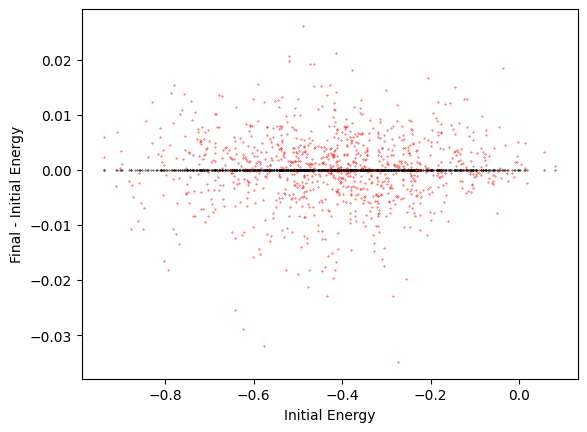

In [74]:
fig,ax = plt.subplots()

ax.scatter(df_a["Ei"], df_a["Ef"]-df_a["Ei"], c="k", s=0.1)
ax.scatter(df_exp["Ei"], df_exp["Ef"]-df_exp["Ei"], c="r", s=0.1)
ax.set_xlabel("Initial Energy")
ax.set_ylabel("Final - Initial Energy")

MSE (Ei): 0.001
KL (Ei): 0.0000
=====
MSE (Ef): 0.005
KL (Ef): 0.0001
=====
MSE (apo): 0.034
KL (apo): 0.0003
=====
MSE (peri): 0.015
KL (peri): 0.0013
=====
MSE (e): 0.011
KL (e): 0.0006
=====


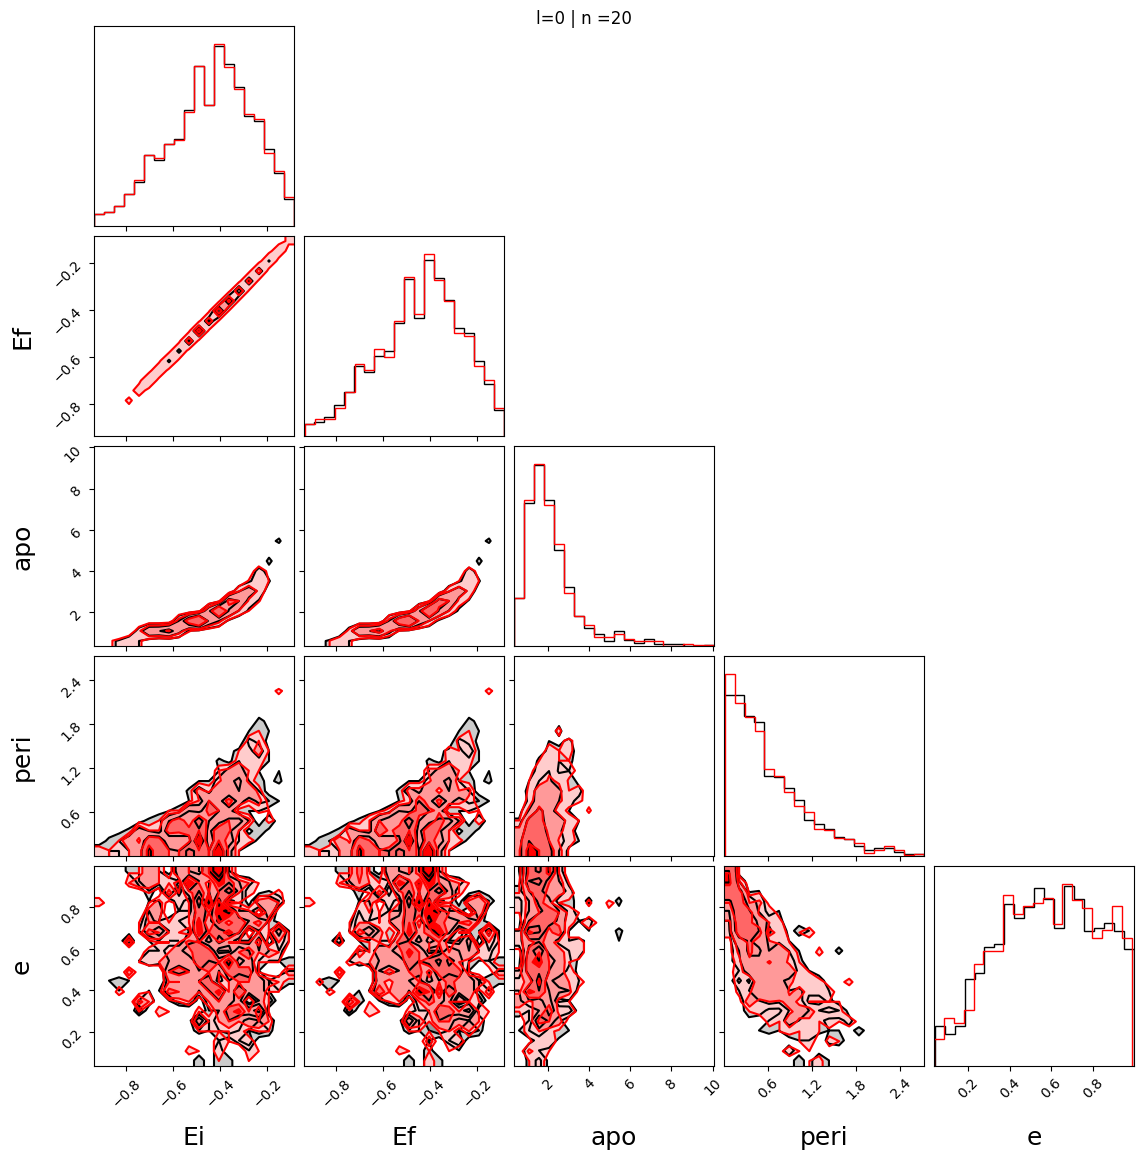

In [75]:
import corner
from scipy.stats import entropy


features = ["Ei", "Ef", "apo", "peri", "e"]
colors = ["k", "r"]

KL = entropy(df_exp[features].values,
             df_a[features].values,
             nan_policy="omit")

common_entries = df_a.dropna(inplace=False).index.intersection(df_exp.dropna(inplace=False).index)
df1 = df_a.loc[common_entries]
df2 = df_exp.loc[common_entries]


for i,df in enumerate([df1, df2]):
    if i ==0:
        fig = corner.corner(df[features].values,
                                        color=colors[i],
                                        labels=features,
                                        bins=20,
                                        plot_contours=True,
                                        plot_datapoints=False,
                                        fill_contours=True,
                                        hist_kwargs={"density": True},
                                        alpha=0.5,
                                        #range=RANGE,
                                        label_kwargs={'fontsize': 18},
                                        )
        
    else:
        corner.corner(df[features].values,
                                        color=colors[i],
                                        labels=features,
                                        bins=20,
                                        plot_contours=True,
                                        plot_datapoints=False,
                                        fill_contours=True,
                                        hist_kwargs={"density": True},
                                        alpha=0.5,
                                        #range=RANGE,
                                        label_kwargs={'fontsize': 18},
                                        fig=fig
                                        )
        
        
fig.suptitle(f"l=0 | n =20")


def mse(x1, x2):
    return np.mean(np.sqrt((x1-x2)**2),axis=0)

for f in features:
    MSE = mse(df2[f].values, 
              df1[f].values)
    KL = entropy(df2[f].values,
                 df1[f].values,
                 nan_policy="omit")
    print(f"MSE ({f}): {MSE:.3f}")
    print(f"KL ({f}): {KL:.4f}")
    print("=====")
    

In [76]:
basis, yaml_file = make_basis(lmax=0, nmax=20)
coefs, coefs_file = get_coefs(radial_period=1, n_snaps_per_period=1, t_start=0)

print(coefs.Times())

exp_units = SimulationUnitSystem(mass=10**12*u.Msun, # Can decide here how big your system is
                                 length=10*u.kpc, # Specify what's the scale radius
                                 G=1)

pot = gp.EXPPotential(units=exp_units,
                      config_file=yaml_file,
                      coef_file=coefs_file)

pot_a = gp.PlummerPotential(m=1,
                            b=1,
                            units=exp_units)

! Scaling:  R= 9.827935816415723   M= 1.0
1.0 0.9685124831368517 0.9685124831368516 0.9685124831368516


---- SLGridSph::ReadH5Cache: error reading </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- SLGridSph::ReadH5Cache: HDF5 error is <Unable to open file /mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0 (File accessibility) Unable to open file>


---- SLGridSph::WriteH5Cache: wrote </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- Spherical::orthoTest: worst=0.00856634
[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0, 85.0, 86.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0, 99.0]
---- SLGridSph::ReadH5Cache: successfully read basis cache </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- Spherical::orthoTest: worst=0.00856634


In [ ]:
from gala.units import SimulationUnitSystem, DimensionlessUnitSystem
import gala.potential as gp
import gala.dynamics as gd
import astropy.units as u
from gala.dynamics import mockstream as ms
import gala.integrate as gi


t1=0
t2=50
n_steps=10000
gc_mass = 1e5*u.Msun

# Initialise simulation submodels
gen_object = ms.MockStreamGenerator(df=ms.ChenStreamDF(lead=True, trail=True), # stream distribution function 
                                    hamiltonian=pot, # potential within which the stream is disrupted
                                    #progenitor_potential=gc_pot 
                                    )
stream_obj, _ = gen_object.run(prog_w0=orbits_ics[0], # initial (or final) phase-space position of the progenitor system
                               prog_mass=gc_mass, # sets the scale mass of the particle release
                               release_every=1, # how many times particles are released at each time step
                               n_particles=1, # how many particles are released by the trail and the lead of the stream each time. Can be an array with same lenth as the timesteps,
                               t1=t1,
                               t2=t2,
                               n_steps = n_steps,
                               Integrator=gi.LeapfrogIntegrator,
                               )  
print(f"Simulation done in {time.time()-start} seconds")

xyz = stream_obj.xyz.to(u.kpc)

_ = stream_obj.plot(s=1)

import astropy.coordinates as coord

stream_obj_obs = stream_obj.to_coord_frame(coord.ICRS())
fig,ax = plt.subplots()
ax.scatter(stream_obj_obs.ra.value,
           stream_obj_obs.dec.value,
           s=1,
           alpha=0.5)

---- SLGridSph::ReadH5Cache: successfully read basis cache </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- Spherical::orthoTest: worst=0.00856634
